# Step 3d — GeneAttention v4: MMD + Centroid + Entropy + Mixup + 2-layer Attention

**Upgrades over v3 (best: Target F1=0.407):**

| Change | Why |
|---|---|
| Multi-scale MMD **+** centroid alignment | v2 proved MMD helps; v3 proved centroid helps — using both is additive |
| 2-layer attention MLP | Deeper gene weighting: `Dense(256)→Dense(128)→Dense(3000)→Softmax(T=2)` |
| Source Mixup (α=0.2) | Interpolated source samples → more robust classifier boundary |
| Entropy weight 0.1→0.15 | Slightly stronger target confidence push |

**Loss:** `CE_mix + 0.3·MMD + 0.3·Centroid + 0.15·Entropy`  (all three alignment terms ramp 0→max over 15 epochs)

In [2]:
import json
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from pathlib import Path
from sklearn.metrics import classification_report, f1_score, confusion_matrix, accuracy_score
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['figure.dpi'] = 120

tf.random.set_seed(42)
np.random.seed(42)

PROJECT_ROOT = Path.cwd().parent.parent if Path.cwd().name == 'step3_self_attention' else Path.cwd()
RESULTS_DIR  = Path('results')
RESULTS_DIR.mkdir(exist_ok=True)
print('Project root:', PROJECT_ROOT)
print('TF:', tf.__version__)

Project root: /Users/kirtan/Projects /NNDL
TF: 2.21.0


## 1. Data + CORAL

In [3]:
X_train = np.load(PROJECT_ROOT / 'step3_X_train.npy').astype(np.float32)
y_train = np.load(PROJECT_ROOT / 'step3_y_train.npy').astype(np.int64)
X_test  = np.load(PROJECT_ROOT / 'step3_X_test.npy').astype(np.float32)
y_test  = np.load(PROJECT_ROOT / 'step3_y_test.npy').astype(np.int64)

with open(PROJECT_ROOT / 'step3_label_mapping.json') as f:
    label_map = json.load(f)
class_names = [label_map[str(i)] for i in range(len(label_map))]
n_classes   = len(class_names)
n_genes     = X_train.shape[1]

X_target_raw = np.load(PROJECT_ROOT / 'gse126030_preprocessed.npy').astype(np.float32)
df_labels    = pd.read_csv(PROJECT_ROOT / 'improvements/1_label_validation/label_validation_output/gse126030_reclustered_labels.csv')
mask         = (df_labels['confidence'] >= 0.55) & (df_labels['new_class'] != 'Uncertain')
y_target_eval = np.array([class_names.index(n) for n in df_labels.loc[mask, 'new_class']], dtype=np.int64)

classes, counts = np.unique(y_train, return_counts=True)
class_weight = {int(c): len(y_train) / (n_classes * cnt) for c, cnt in zip(classes, counts)}

def coral_align(X_src, X_tgt, reg=1e-3):
    src_mean = X_src.mean(axis=0)
    Xs = X_src - src_mean
    Xt = X_tgt - X_tgt.mean(axis=0)
    Cs = (Xs.T @ Xs) / (Xs.shape[0]-1) + reg*np.eye(Xs.shape[1])
    Ct = (Xt.T @ Xt) / (Xt.shape[0]-1) + reg*np.eye(Xt.shape[1])
    def msqrt(M):
        v, V = np.linalg.eigh(M); return V @ np.diag(np.sqrt(np.maximum(v, 0))) @ V.T
    def minvsqrt(M):
        v, V = np.linalg.eigh(M); return V @ np.diag(1/np.sqrt(np.maximum(v, 1e-10))) @ V.T
    return ((Xt @ (minvsqrt(Ct) @ msqrt(Cs))) + src_mean).astype(np.float32)

print('Running CORAL...')
X_target_coral = coral_align(X_train, X_target_raw)
X_target_eval  = X_target_coral[mask.values]
print(f'Train:{X_train.shape}  Target eval:{X_target_eval.shape}')

Running CORAL...
Train:(6824, 3000)  Target eval:(12776, 3000)


## 2. σ Calibration (2-layer attention probe)

In [4]:
def make_probe(n_genes):
    inp     = keras.Input(shape=(n_genes,))
    h       = layers.Dense(256, activation='relu')(inp)
    h       = layers.Dropout(0.3)(h)
    h       = layers.Dense(128, activation='relu')(h)   # 2nd attention layer
    att_log = layers.Dense(n_genes)(h)
    w       = layers.Softmax(axis=-1)(att_log / 2.0)
    x_res   = inp * w * n_genes + inp
    z = layers.Dense(512, activation='relu')(x_res)
    z = layers.LayerNormalization()(z)
    z = layers.Dropout(0.4)(z)
    z = layers.Dense(256, activation='relu')(z)
    z = layers.LayerNormalization()(z)
    z = layers.Dropout(0.3)(z)
    z = layers.Dense(128, activation='relu', name='latent')(z)
    return keras.Model(inp, z)

_probe = make_probe(n_genes)

idx_s = np.random.choice(len(X_train),        1000, replace=False)
idx_t = np.random.choice(len(X_target_coral), 1000, replace=False)
z_all = np.concatenate([
    _probe(X_train[idx_s],        training=False).numpy(),
    _probe(X_target_coral[idx_t], training=False).numpy(),
], axis=0)

sub   = z_all[np.random.choice(len(z_all), 500, replace=False)]
diffs = sub[:, None, :] - sub[None, :, :]
dists = np.sqrt((diffs**2).sum(axis=-1))
upper = dists[np.triu_indices(500, k=1)]
median_dist = float(np.median(upper))

SIGMAS = [median_dist/4, median_dist/2, median_dist, median_dist*2]
print(f'Median pairwise L2: {median_dist:.4f}')
print(f'Calibrated σ: {[round(s,4) for s in SIGMAS]}')
del _probe

Median pairwise L2: 10.7182
Calibrated σ: [2.6795, 5.3591, 10.7182, 21.4364]


## 3. GeneAttentionV4 Model

In [5]:
def mmd_rbf(x, y, sigmas):
    """Multi-scale RBF MMD between rows of x and y."""
    loss = tf.constant(0.0)
    for s in sigmas:
        def k(a, b):
            sq = tf.reduce_sum(tf.square(tf.expand_dims(a,1) - tf.expand_dims(b,0)), axis=-1)
            return tf.exp(-sq / (2.0 * s * s))
        loss += tf.reduce_mean(k(x,x)) + tf.reduce_mean(k(y,y)) - 2.0*tf.reduce_mean(k(x,y))
    return loss / float(len(sigmas))


class GeneAttentionV4(keras.Model):
    def __init__(self, n_genes, n_classes, sigmas,
                 att_temp=2.0,
                 max_mmd_weight=0.3,
                 max_align_weight=0.3,
                 max_ent_weight=0.15,
                 ramp_epochs=15,
                 mixup_alpha=0.2,
                 class_weight_dict=None, **kwargs):
        super().__init__(**kwargs)
        self.n_genes          = n_genes
        self.n_classes        = n_classes
        self.sigmas           = [tf.constant(float(s), dtype=tf.float32) for s in sigmas]
        self.att_temp         = att_temp
        self.max_mmd_weight   = max_mmd_weight
        self.max_align_weight = max_align_weight
        self.max_ent_weight   = max_ent_weight
        self.ramp_epochs      = tf.constant(float(ramp_epochs), dtype=tf.float32)
        self.mixup_alpha      = mixup_alpha
        self.current_epoch    = tf.Variable(0.0, trainable=False, dtype=tf.float32)

        if class_weight_dict is not None:
            cw = np.array([class_weight_dict[i] for i in range(n_classes)], dtype=np.float32)
            self.cw = tf.constant(cw)
        else:
            self.cw = None

        # 2-layer attention MLP
        self.att_h1    = layers.Dense(256, activation='relu')
        self.att_drp1  = layers.Dropout(0.3)
        self.att_h2    = layers.Dense(128, activation='relu')
        self.att_drp2  = layers.Dropout(0.2)
        self.att_logits = layers.Dense(n_genes)

        # Classifier trunk (unchanged from v3)
        self.d1  = layers.Dense(512, activation='relu')
        self.ln1 = layers.LayerNormalization()
        self.dr1 = layers.Dropout(0.4)
        self.d2  = layers.Dense(256, activation='relu')
        self.ln2 = layers.LayerNormalization()
        self.dr2 = layers.Dropout(0.3)
        self.d3  = layers.Dense(128, activation='relu', name='latent')
        self.dr3 = layers.Dropout(0.2)
        self.out = layers.Dense(n_classes, activation='softmax')

        # Metrics
        self.loss_t   = keras.metrics.Mean(name='loss')
        self.ce_t     = keras.metrics.Mean(name='ce_loss')
        self.mmd_t    = keras.metrics.Mean(name='mmd_loss')
        self.align_t  = keras.metrics.Mean(name='align_loss')
        self.ent_t    = keras.metrics.Mean(name='ent_loss')
        self.acc_t    = keras.metrics.SparseCategoricalAccuracy(name='accuracy')

    @property
    def metrics(self):
        return [self.loss_t, self.ce_t, self.mmd_t, self.align_t, self.ent_t, self.acc_t]

    def encode(self, x, training=False):
        h   = self.att_h1(x)
        h   = self.att_drp1(h, training=training)
        h   = self.att_h2(h)
        h   = self.att_drp2(h, training=training)
        w   = tf.nn.softmax(self.att_logits(h) / self.att_temp, axis=-1)
        x_r = x * w * self.n_genes + x         # attended + residual
        z   = self.dr1(self.ln1(self.d1(x_r)), training=training)
        z   = self.dr2(self.ln2(self.d2(z)),   training=training)
        z   = self.dr3(self.d3(z),             training=training)
        return z

    def call(self, x, training=False):
        return self.out(self.encode(x, training=training))

    def _mmd(self, z_src, z_tgt):
        return mmd_rbf(z_src, z_tgt, self.sigmas)

    def _centroid_alignment(self, z_src, src_y, z_tgt, y_pred_tgt):
        total = tf.constant(0.0)
        count = tf.constant(0.0)
        for k in range(self.n_classes):
            src_mask  = tf.cast(tf.equal(src_y, k), tf.float32)
            src_count = tf.reduce_sum(src_mask)
            src_cent  = tf.reduce_sum(z_src * src_mask[:, None], 0) / (src_count + 1e-8)
            tgt_w     = y_pred_tgt[:, k]
            tgt_sum   = tf.reduce_sum(tgt_w)
            tgt_cent  = tf.reduce_sum(z_tgt * tgt_w[:, None], 0) / (tgt_sum + 1e-8)
            valid     = tf.cast(src_count >= 1.0, tf.float32) * tf.cast(tgt_sum > 1e-6, tf.float32)
            total    += valid * tf.reduce_mean(tf.square(src_cent - tgt_cent))
            count    += valid
        return total / (count + 1e-8)

    def _mixup_ce(self, x, y, training):
        """Mixup: interpolate two shuffled copies of the batch, use soft CE."""
        batch_size = tf.shape(x)[0]
        # Sample λ ~ Beta(α, α) via ratio of Gamma samples
        alpha = self.mixup_alpha
        g1  = tf.random.gamma([batch_size], alpha)
        g2  = tf.random.gamma([batch_size], alpha)
        lam = g1 / (g1 + g2 + 1e-8)                   # (B,)
        lam = tf.maximum(lam, 1.0 - lam)               # always ≥ 0.5 — dominant sample stays dominant

        idx  = tf.random.shuffle(tf.range(batch_size))
        x2   = tf.gather(x, idx)
        y2   = tf.cast(tf.gather(y, idx), tf.int32)

        lam_x = tf.reshape(lam, [-1, 1])
        x_mix = lam_x * x + (1.0 - lam_x) * x2

        z_mix  = self.encode(x_mix, training=training)
        y_pred = self.out(z_mix)

        # Soft CE: −[λ·log p(y1) + (1−λ)·log p(y2)]
        y1_oh  = tf.one_hot(tf.cast(y,  tf.int32), self.n_classes)
        y2_oh  = tf.one_hot(tf.cast(y2, tf.int32), self.n_classes)
        log_p  = tf.math.log(y_pred + 1e-8)
        per_sample = -tf.reduce_sum(
            lam[:, None] * y1_oh * log_p + (1.0 - lam[:, None]) * y2_oh * log_p, axis=1
        )
        if self.cw is not None:
            # weight by dominant class
            w = tf.gather(self.cw, tf.cast(y, tf.int32))
            return tf.reduce_mean(per_sample * w)
        return tf.reduce_mean(per_sample)

    def train_step(self, data):
        (src_x, src_y), (tgt_x,) = data

        progress     = tf.minimum(self.current_epoch / self.ramp_epochs, 1.0)
        mmd_w    = self.max_mmd_weight   * progress
        align_w  = self.max_align_weight * progress
        ent_w    = self.max_ent_weight   * progress

        with tf.GradientTape() as tape:
            # Source: encode for alignment + mixup CE
            z_src      = self.encode(src_x, training=True)
            z_tgt      = self.encode(tgt_x, training=True)
            y_pred_tgt = self.out(z_tgt)

            ce_loss    = self._mixup_ce(src_x, src_y, training=True)
            mmd_loss   = self._mmd(z_src, z_tgt)
            align_loss = self._centroid_alignment(z_src, src_y, z_tgt, y_pred_tgt)
            ent_loss   = -tf.reduce_mean(
                tf.reduce_sum(y_pred_tgt * tf.math.log(y_pred_tgt + 1e-8), axis=1)
            )

            total = ce_loss + mmd_w * mmd_loss + align_w * align_loss + ent_w * ent_loss

        grads = tape.gradient(total, self.trainable_variables)
        grads, _ = tf.clip_by_global_norm(grads, 1.0)
        self.optimizer.apply_gradients(zip(grads, self.trainable_variables))

        # For accuracy tracking, use un-mixed source predictions
        y_pred_src = self(src_x, training=False)
        self.loss_t.update_state(total)
        self.ce_t.update_state(ce_loss)
        self.mmd_t.update_state(mmd_loss)
        self.align_t.update_state(align_loss)
        self.ent_t.update_state(ent_loss)
        self.acc_t.update_state(src_y, y_pred_src)
        return {m.name: m.result() for m in self.metrics}

    def test_step(self, data):
        x, y   = data
        y_pred = self(x, training=False)
        loss   = tf.reduce_mean(
            keras.losses.sparse_categorical_crossentropy(y, y_pred)
        )
        self.ce_t.update_state(loss)
        self.acc_t.update_state(y, y_pred)
        return {'ce_loss': self.ce_t.result(), 'accuracy': self.acc_t.result()}


print('GeneAttentionV4 defined.')

GeneAttentionV4 defined.


## 4. Instantiate + Datasets + Callbacks

In [6]:
BATCH_SIZE  = 128
MAX_EPOCHS  = 120
PATIENCE    = 20
RAMP_EPOCHS = 15

model = GeneAttentionV4(
    n_genes=n_genes, n_classes=n_classes, sigmas=SIGMAS,
    att_temp=2.0,
    max_mmd_weight=0.3,
    max_align_weight=0.3,
    max_ent_weight=0.15,
    ramp_epochs=RAMP_EPOCHS,
    mixup_alpha=0.2,
    class_weight_dict=class_weight,
    name='GeneAttentionV4',
)
model.compile(optimizer=keras.optimizers.Adam(2e-4, clipnorm=1.0))

src_ds = (
    tf.data.Dataset.from_tensor_slices((X_train, y_train))
    .shuffle(10000, seed=42)
    .batch(BATCH_SIZE, drop_remainder=True)
)
tgt_ds = (
    tf.data.Dataset.from_tensor_slices((X_target_coral,))
    .shuffle(100000, seed=42)
    .batch(BATCH_SIZE, drop_remainder=True)
    .repeat()
)
train_ds = tf.data.Dataset.zip((src_ds, tgt_ds))
val_ds   = tf.data.Dataset.from_tensor_slices((X_test, y_test)).batch(BATCH_SIZE)


class EpochRampCallback(keras.callbacks.Callback):
    def on_epoch_begin(self, epoch, logs=None):
        self.model.current_epoch.assign(float(epoch))
        if epoch <= RAMP_EPOCHS or epoch % 10 == 0:
            p = min(epoch / RAMP_EPOCHS, 1.0)
            print(f'  [ep={epoch} mmd_w={0.3*p:.3f} align_w={0.3*p:.3f} ent_w={0.15*p:.3f}]', end='')


callbacks = [
    EpochRampCallback(),
    keras.callbacks.EarlyStopping(
        monitor='val_ce_loss', mode='min',
        patience=PATIENCE, restore_best_weights=True, verbose=1
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor='val_ce_loss', mode='min',
        factor=0.5, patience=8, min_lr=1e-6, verbose=1
    ),
]
print(f'Steps per epoch: {len(src_ds)}')

Steps per epoch: 53


## 5. Training

In [7]:
history = model.fit(
    train_ds, epochs=MAX_EPOCHS,
    validation_data=val_ds,
    callbacks=callbacks,
    verbose=1,
)

  [ep=0 mmd_w=0.000 align_w=0.000 ent_w=0.000]Epoch 1/120
53/53 ━━━━━━━━━━━━━━━━━━━━ 5s 36ms/step - accuracy: 0.4965 - align_loss: 0.0773 - ce_loss: 1.8390 - ent_loss: 1.1580 - loss: 1.8390 - mmd_loss: 0.0111 - val_accuracy: 0.6981 - val_ce_loss: 0.8045 - learning_rate: 2.0000e-04
  [ep=1 mmd_w=0.020 align_w=0.020 ent_w=0.010]Epoch 2/120
53/53 ━━━━━━━━━━━━━━━━━━━━ 2s 34ms/step - accuracy: 0.8353 - align_loss: 0.0873 - ce_loss: 1.0374 - ent_loss: 1.0226 - loss: 1.0496 - mmd_loss: 0.0113 - val_accuracy: 0.8148 - val_ce_loss: 0.4952 - learning_rate: 2.0000e-04
  [ep=2 mmd_w=0.040 align_w=0.040 ent_w=0.020]Epoch 3/120
53/53 ━━━━━━━━━━━━━━━━━━━━ 2s 34ms/step - accuracy: 0.9164 - align_loss: 0.1012 - ce_loss: 0.7659 - ent_loss: 0.8691 - loss: 0.7878 - mmd_loss: 0.0118 - val_accuracy: 0.8675 - val_ce_loss: 0.3525 - learning_rate: 2.0000e-04
  [ep=3 mmd_w=0.060 align_w=0.060 ent_w=0.030]Epoch 4/120
53/53 ━━━━━━━━━━━━━━━━━━━━ 2s 35ms/step - accuracy: 0.9527 - align_loss: 0.1143 - ce_loss: 0.614

## 6. Training Curves

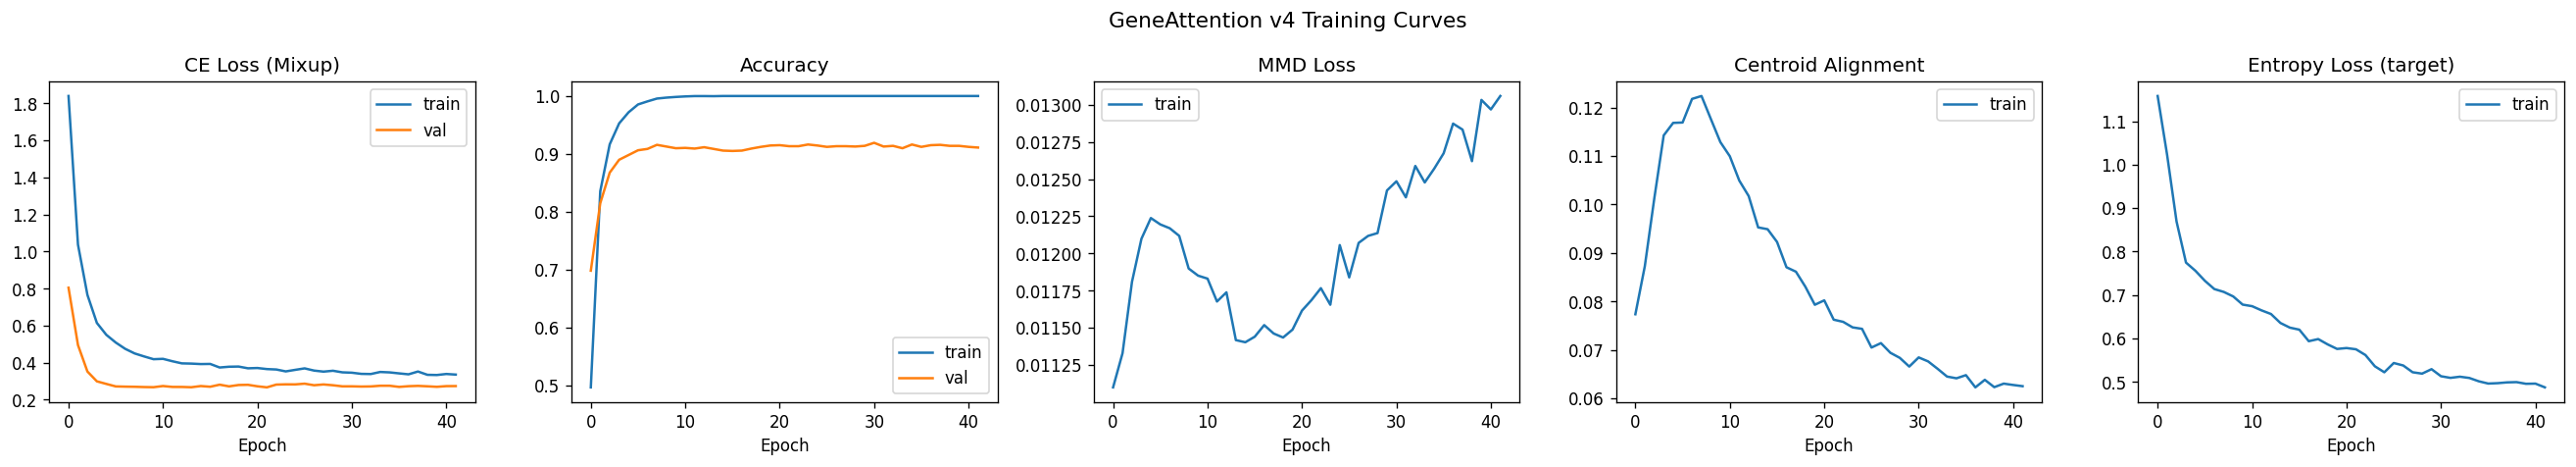

Trained for 42 epochs.


In [8]:
fig, axes = plt.subplots(1, 5, figsize=(22, 4))
for ax, k, t in [
    (axes[0], 'ce_loss',    'CE Loss (Mixup)'),
    (axes[1], 'accuracy',   'Accuracy'),
    (axes[2], 'mmd_loss',   'MMD Loss'),
    (axes[3], 'align_loss', 'Centroid Alignment'),
    (axes[4], 'ent_loss',   'Entropy Loss (target)'),
]:
    ax.plot(history.history[k], label='train')
    if f'val_{k}' in history.history:
        ax.plot(history.history[f'val_{k}'], label='val')
    ax.set_title(t); ax.set_xlabel('Epoch'); ax.legend()
plt.suptitle('GeneAttention v4 Training Curves', fontsize=13)
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'training_curves_v4.png', bbox_inches='tight')
plt.show()
print(f'Trained for {len(history.history["ce_loss"])} epochs.')

## 7. Evaluation

In [9]:
y_pred_src = np.argmax(model.predict(X_test,        batch_size=BATCH_SIZE), axis=1)
y_pred_tgt = np.argmax(model.predict(X_target_eval, batch_size=BATCH_SIZE), axis=1)
src_f1 = f1_score(y_test,        y_pred_src, average='macro')
tgt_f1 = f1_score(y_target_eval, y_pred_tgt, average='macro')

print(f'Source F1: {src_f1:.4f}   Target F1: {tgt_f1:.4f}')
print('\n--- Source ---')
print(classification_report(y_test, y_pred_src, target_names=class_names))
print('\n--- Target ---')
print(classification_report(y_target_eval, y_pred_tgt, target_names=class_names))

14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
Source F1: 0.9034   Target F1: 0.4202

--- Source ---
              precision    recall  f1-score   support

    Effector       0.94      0.97      0.95       482
   Exhausted       0.94      0.93      0.93       166
       Naive       0.88      0.82      0.85       224
   Other_CD4       0.84      0.87      0.86       321
    Th1-like       0.91      0.85      0.88       141
        Treg       0.95      0.95      0.95       372

    accuracy                           0.91      1706
   macro avg       0.91      0.90      0.90      1706
weighted avg       0.91      0.91      0.91      1706


--- Target ---
              precision    recall  f1-score   support

    Effector       0.55      0.63      0.59      2839
   Exhausted       0.04      0.04      0.04       903
       Naive       0.88      0.55      0.68      3806
   Other_CD4       0.47      0.50      0.48      2127
    Th1-like       0.20      0.15   

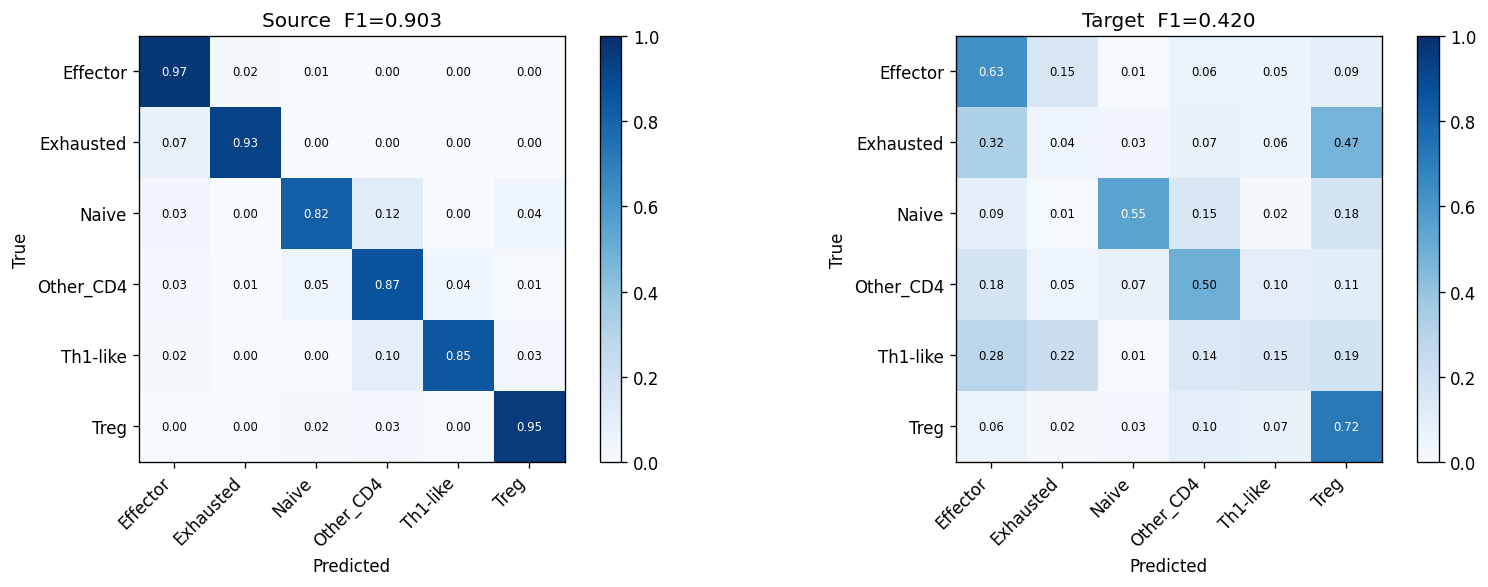

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, y_true, y_pred, title in [
    (axes[0], y_test,        y_pred_src, f'Source  F1={src_f1:.3f}'),
    (axes[1], y_target_eval, y_pred_tgt, f'Target  F1={tgt_f1:.3f}'),
]:
    cm = confusion_matrix(y_true, y_pred, normalize='true')
    im = ax.imshow(cm, cmap='Blues', vmin=0, vmax=1)
    ax.set_title(title)
    ax.set_xticks(range(n_classes)); ax.set_yticks(range(n_classes))
    ax.set_xticklabels(class_names, rotation=45, ha='right')
    ax.set_yticklabels(class_names)
    ax.set_xlabel('Predicted'); ax.set_ylabel('True')
    for i in range(n_classes):
        for j in range(n_classes):
            ax.text(j, i, f'{cm[i,j]:.2f}', ha='center', va='center',
                    color='white' if cm[i,j] > 0.5 else 'black', fontsize=7)
    plt.colorbar(im, ax=ax)
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'confusion_matrices_v4.png', bbox_inches='tight')
plt.show()

## 8. Save + Full Comparison Table

In [11]:
src_rep = classification_report(y_test,        y_pred_src, target_names=class_names, output_dict=True)
tgt_rep = classification_report(y_target_eval, y_pred_tgt, target_names=class_names, output_dict=True)

results = {
    'model': 'GeneAttentionV4',
    'config': {
        'sigmas': SIGMAS, 'median_dist': median_dist,
        'att_temp': 2.0, 'att_layers': 2,
        'max_mmd_weight': 0.3, 'max_align_weight': 0.3, 'max_ent_weight': 0.15,
        'ramp_epochs': RAMP_EPOCHS, 'mixup_alpha': 0.2,
        'coral': True, 'epochs_trained': len(history.history['ce_loss']),
    },
    'source_test': {
        'macro_f1': float(src_f1),
        'accuracy': float(accuracy_score(y_test, y_pred_src)),
        'per_class_f1': {c: src_rep[c]['f1-score'] for c in class_names},
    },
    'target_eval': {
        'macro_f1': float(tgt_f1),
        'accuracy': float(accuracy_score(y_target_eval, y_pred_tgt)),
        'per_class_f1': {c: tgt_rep[c]['f1-score'] for c in class_names},
    },
}
with open(RESULTS_DIR / 'gene_attention_v4_results.json', 'w') as f:
    json.dump(results, f, indent=2)
model.save_weights(str(RESULTS_DIR / 'gene_attention_v4.weights.h5'))

# ── Full comparison table ────────────────────────────────────────────────────
all_models = [
    ('LogReg',                           0.885, None),
    ('MLP',                              0.884, None),
    ('DANN v1',                          0.852, 0.391),
    ('DANN v2',                          0.875, 0.395),
    ('GeneAtt v1 (no align)',            0.894, 0.079),
    ('GeneAtt v2 (CORAL+MMD)',           0.893, 0.404),
    ('PatchTransformer',                 0.772, 0.384),
    ('VAE + Classifier',                 0.881, 0.383),
    ('GeneAtt v3 (centroid+ent)',        0.896, 0.407),
    ('GeneAtt v4 (MMD+centroid+mixup)',  src_f1, tgt_f1),
]

best_tgt = max(t for _, _, t in all_models if t is not None)
print(f'\n{"Model":40s} {"Source F1":>10s} {"Target F1":>10s}')
print('-' * 65)
for name, sf, tf_ in all_models:
    s = f'{sf:.3f}' if sf is not None else '   —  '
    t = f'{tf_:.3f}' if tf_ is not None else '   —  '
    mark = ' ◄ best' if tf_ is not None and abs(tf_ - best_tgt) < 1e-9 else ''
    print(f'{name:40s} {s:>10s} {t:>10s}{mark}')


Model                                     Source F1  Target F1
-----------------------------------------------------------------
LogReg                                        0.885        —  
MLP                                           0.884        —  
DANN v1                                       0.852      0.391
DANN v2                                       0.875      0.395
GeneAtt v1 (no align)                         0.894      0.079
GeneAtt v2 (CORAL+MMD)                        0.893      0.404
PatchTransformer                              0.772      0.384
VAE + Classifier                              0.881      0.383
GeneAtt v3 (centroid+ent)                     0.896      0.407
GeneAtt v4 (MMD+centroid+mixup)               0.903      0.420 ◄ best
